#  Indian House Rent Prediction
## End-to-End Machine Learning Project

**Goal:** Predict monthly rent (₹) for Indian residential properties using structured listing data.

**Dataset columns:**
- `bhk` — Bedrooms, Hall, Kitchen count
- `rent` — Monthly rent in ₹ (target)
- `size` — Property size in sq ft
- `floor` — Floor info e.g. "3 out of 10"
- `area_type` — Super Area / Carpet Area / Built Area
- `area_locality` — Neighbourhood name (high cardinality)
- `city` — City name (noisy strings)
- `furnishing_status` — Furnished / Semi-Furnished / Unfurnished
- `tenant_preferred` — Bachelors / Family / Bachelors&Family
- `bathroom` — Number of bathrooms
- `point_of_contact` — Contact Agent / Contact Owner

**Pipeline overview:**
1. Data Cleaning → 2. EDA → 3. Feature Engineering → 4. Train/Test Split → 5. Outlier Capping → 6. Preprocessing Pipeline → 7. Model Comparison → 8. Hyperparameter Tuning


# 1. Imports & Data Loading

In [78]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from thefuzz import process  # fuzzy string matching for noisy city/tenant columns

df = pd.read_csv("Indian_House_Rent_Dataset.csv")

# 2. Initial Exploration

In [107]:
df['rent'].median()

np.float64(16000.0)

In [79]:
# Standardise column names: lowercase + underscores
df.columns = df.columns.str.lower().str.replace(" ", "_")

# Drop exact duplicate rows before any analysis
df = df.drop_duplicates()

df.head(10)

,posted_on,bhk,size,floor,area_type,area_locality,city,furnishing_status,tenant_preferred,bathroom,point_of_contact,rent
0,NaN,2.0,1100.0,NaN,Super Area,Bandel,India-! Kolkata,Unfurnished,Bach^elors/Fam.ily,2.0,Contact Owner,10000
1,2022-05-13,2.0,800.0,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",India-! Kolkata,Semi-Furnished,Bachelors\/Family*,NaN,NaN,20000
2,2022-05-16,2.0,1000.0,1 out of 3,Super Area,Salt Lake City Sector 2,India-- Kolkata,Semi-Furnished,NaN,1.0,Contact Owner,17000
3,2022-07-04,2.0,800.0,1 out of 2,Super Area,NaN,NaN,Unfurnished,Bachel]ors/F@amily,1.0,NaN,10000
4,2022-05-09,2.0 room,850.0,1 out of 2,Carpet Area,South Dum Dum,India-^ Kolkata,Unfurnished,Bache[lors&,1.0,Contact Owner,7500
5,2022-04-29,2.0,600.0,Ground out of 1,Super Area,Thakurpukur,India-\ Kolkata,Unfurnished,Bachelors/F}amily+,2.0,Contact Owner,7000
6,2022-06-21,2.0,700.0,Ground out of 4,Super Area,NaN,India-% Kolkata,Unfurnished,Bach@=elors,2.0,Contact Agent,10000
7,2022-06-21,1.0,250.0,1 out of 2,Super Area,Malancha,",-9 Kolkata",Unfurnished,NaN,1.0 Bathrooms,Contact Agent,5000
8,2022-06-07,2.0,NaN,1 out of 2,Carpet Area,"Palm Avenue Kolkata, Ballygunge",NaN,Unfurnished,"?Bachelor,s",2.0,Contact Agent,26000
9,NaN,NaN,1000.0,1 out of 3,Carpet Area,Natunhat,",-9 Kolkata",Semi-Furnished,NaN,2.0,Contact Owner,10000


In [80]:
# Check dtypes and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   posted_on          4084 non-null   str  
 1   bhk                3963 non-null   str  
 2   size               3826 non-null   str  
 3   floor              3960 non-null   str  
 4   area_type          3804 non-null   str  
 5   area_locality      4146 non-null   str  
 6   city               4091 non-null   str  
 7   furnishing_status  4042 non-null   str  
 8   tenant_preferred   4094 non-null   str  
 9   bathroom           4205 non-null   str  
 10  point_of_contact   4137 non-null   str  
 11  rent               4746 non-null   int64
dtypes: int64(1), str(11)
memory usage: 445.1 KB


In [81]:
# Count missing values per column
# NOTE: Many columns have NaNs from noisy string parsing — handled per column below
df.isna().sum()

posted_on            662
bhk                  783
size                 920
floor                786
area_type            942
area_locality        600
city                 655
furnishing_status    704
tenant_preferred     652
bathroom             541
point_of_contact     609
rent                   0
dtype: int64

# 3. Data Cleaning

Each column has a different type of noise — handled individually below.

**Key decisions made:**
- `bhk`, `size`, `bathroom`: stripped non-numeric characters then cast to float
- `floor`: parsed into `floor_number` (numeric) + `total_floors` extracted later for feature engineering
- `city`: lowercased → regex stripped prefix noise → fuzzy matched to known city list
- `tenant_preferred`: fuzzy matched to 3 clean categories
- `area_type`: lowercased to collapse SUPER AREA / Super Area duplicates
- `furnishing_status`, `point_of_contact`, `city`, `tenant_preferred`: cast to `category` dtype
  → saves memory, useful for pandas operations, but sklearn still needs explicit encoding in pipeline


### 3.1 `posted_on` — convert to datetime

In [82]:
# Will be used later to engineer post_month and days_since_posted features
df['posted_on'] = pd.to_datetime(df['posted_on'], errors='coerce')

### 3.2 `bhk` — strip noise, cast to numeric

In [83]:
# Raw values contain symbols like '!2', '3@' — strip everything except digits
df['bhk'] = df['bhk'].astype(str).str.replace(r"[^0-9.]", "", regex=True)
df['bhk'] = pd.to_numeric(df['bhk'], errors='coerce')
df['bhk'].unique()

array([ 2.,  1., nan,  3.,  6.,  4.,  5.])

### 3.3 `size` — strip noise, cast to numeric

In [84]:
df['size'] = df['size'].astype(str).str.replace(r"[^0-9.]", "", regex=True)
df['size'] = pd.to_numeric(df['size'], errors='coerce')

### 3.4 `floor` — extract numeric floor number

In [85]:
# Raw format: "3 out of 10", "Ground out of 5", "Upper Basement out of 2"
# We extract floor_number here — total_floors extracted later in feature engineering
# floor_number is kept temporarily only for floor_ratio calculation, then dropped

pattern = r"(\d+)\s+out\s+of\s+\d+"
df['floor_number'] = df['floor'].astype(str).str.extract(pattern)

# Map special floor names to numeric equivalents
df.loc[df['floor'].astype(str).str.contains('Ground', na=False), 'floor_number'] = '0'
df.loc[df['floor'].astype(str).str.contains('Upper Basement', na=False), 'floor_number'] = '-1'
df.loc[df['floor'].astype(str).str.contains('Lower Basement', na=False), 'floor_number'] = '-2'

df['floor_number'] = pd.to_numeric(df['floor_number'], errors='coerce')

### 3.5 `area_locality` — normalise

In [86]:
# 2012 unique values — too high cardinality for OHE
# Will be handled with TargetEncoder inside the pipeline (replaces locality with mean rent)
# Normalise here: lowercase + strip whitespace
df['area_locality'] = df['area_locality'].str.lower().str.strip()
# NOTE: do NOT fillna here — SimpleImputer inside the pipeline handles missing values
# to avoid any data leakage from the test set
df['area_locality'].nunique()

2012

### 3.6 `city` — fuzzy match against known cities

In [87]:
# Raw values have noise like "India-! Kolkata", "mumb@i" etc.
# Step 1: lowercase
# Step 2: regex strips everything before the last word (handles prefix noise)
# Step 3: fuzzy match against known city list with 80% similarity threshold
# Step 4: unmatched cities → NaN (only 6 cities in dataset anyway)

df['city'] = df['city'].astype(str).str.lower()
df['city'] = df['city'].str.replace(r".*?([a-z]+)$", r"\1", regex=True)

cities = [
    "mumbai", "delhi", "bangalore", "kolkata", "chennai",
    "ahmedabad", "hyderabad", "pune", "surat", "kanpur",
    "jaipur", "lucknow", "nagpur", "indore", "patna"
]

for city_bad in df['city'].unique():
    if pd.notna(city_bad) and isinstance(city_bad, str) and city_bad.strip():
        result = process.extractOne(city_bad, cities)
        if result and result[1] > 80:
            df.loc[df['city'] == city_bad, 'city'] = result[0]

df.loc[~df['city'].isin(cities), 'city'] = np.nan

# category dtype: saves memory, preserves distribution info
# NOTE: category is NOT directly usable by sklearn — OneHotEncoder in pipeline handles that
df['city'] = df['city'].astype('category')
df['city'].value_counts()

city
mumbai       829
chennai      767
hyderabad    763
bangalore    761
delhi        527
kolkata      444
Name: count, dtype: int64

### 3.7 `furnishing_status` — cast to category

In [88]:
# 3 ordered values: Unfurnished < Semi-Furnished < Furnished
# Kept as category here — OrdinalEncoder in pipeline assigns 0/1/2 in correct order
df['furnishing_status'] = df['furnishing_status'].astype('category')

### 3.8 `tenant_preferred` — fuzzy match then cast to category

In [89]:
# Raw values are heavily noisy: '!Bachelo<rs/Family', '"Fa;mily' etc.
# Only 3 real categories exist in the data: Bachelors, Family, Bachelors/Family
# NOTE: 'Couples' was investigated and confirmed to have 0 rows — dead category

category = ['Bachelors/Family', 'Family', 'Bachelors', 'Couples']
for status in df['tenant_preferred'].dropna().unique():
    if isinstance(status, str):
        result = process.extractOne(status, category)
        if result and result[1] > 80:
            df.loc[df['tenant_preferred'] == status, 'tenant_preferred'] = result[0]

df['tenant_preferred'] = df['tenant_preferred'].astype('category')

### 3.9 `bathroom` — strip noise, cast to numeric

In [90]:
df['bathroom'] = df['bathroom'].astype(str).str.replace(r"[^0-9.]", "", regex=True)
df['bathroom'] = pd.to_numeric(df['bathroom'], errors='coerce')

### 3.10 `point_of_contact` & `area_type` — cast to category

In [91]:
df['point_of_contact'] = df['point_of_contact'].astype('category')

# str.lower() before astype collapses 'SUPER AREA' and 'Super Area' into one category
df['area_type'] = df['area_type'].str.lower().astype('category')
df['area_type'].unique()

['super area', 'carpet area', NaN, 'built area']
Categories (3, str): ['built area', 'carpet area', 'super area']

# 4. Outlier Removal

**`built area` has only 2 rows** — statistically meaningless and causes issues in
stratified CV splits. Drop before any modelling.

**BHK/bathroom filter:**
- We use `~(> 5)` instead of `(<= 5)` to avoid silently dropping NaN rows
- `df['bhk'] <= 5` returns False for NaN → drops 1241 NaN rows unintentionally
- `~(df['bhk'] > 5)` returns True for NaN → keeps them for the imputer to handle


In [92]:
# Drop the 2 'built area' rows — too few to be useful
df = df[df['area_type'] != 'built area']

# Keep rows where BHK/bathroom are either NaN (imputer handles) or ≤ 5
# Do NOT use df[(df['bhk'] <= 5) & (df['bathroom'] <= 5)] — that silently drops NaN rows
df = df[~((df['bhk'] > 5) | (df['bathroom'] > 5))]

print(df.shape)

(4728, 13)


# 5. Exploratory Data Analysis (EDA)

Key findings from EDA:
- `rent` is heavily right-skewed (skewness ~3.6) → needs log transform
- `size` is moderately skewed (1.42) → log overcorrects to -1.07, so we keep size as-is
- `bathroom` has the strongest correlation with rent (0.70) — stronger than BHK
- `city_mumbai` is a massive outlier — mean rent ~₹80K vs ₹20K for other cities
- `BHK=5` and `bathroom=5` are rare but show a strong price jump — keep them
- `total_floors` (0.56) correlates with rent better than `floor_number` (0.50)
  → taller buildings tend to be newer/luxury


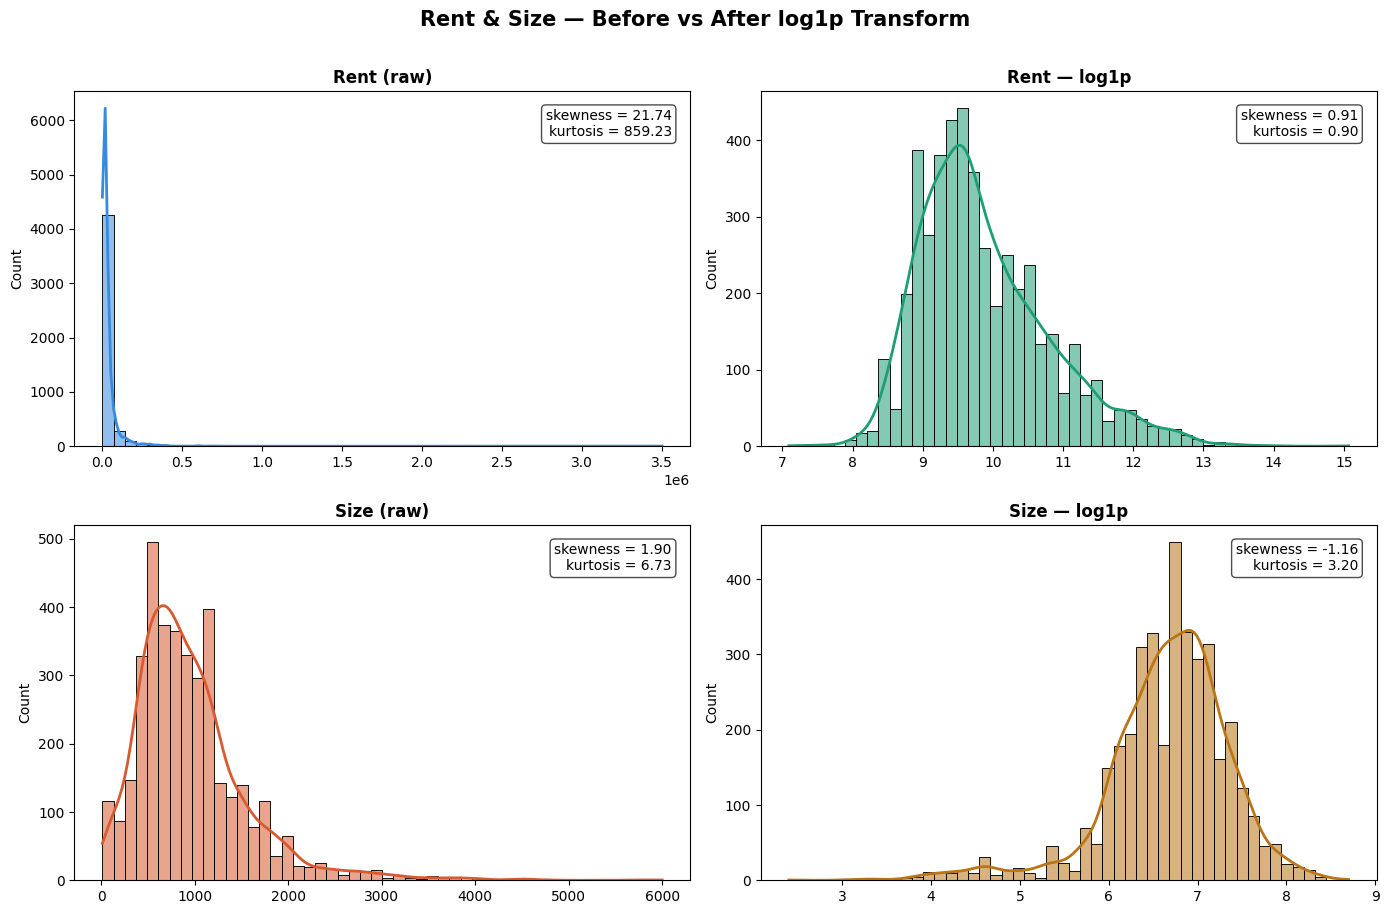

In [93]:
# Distribution: rent before vs after log transform
rent_log = np.log1p(df['rent'])
size_log = np.log1p(df['size'])

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Rent & Size — Before vs After log1p Transform',
             fontsize=15, fontweight='bold', y=1.01)

pairs = [
    (axes[0, 0], df['rent'], 'Rent (raw)',    '#378ADD'),
    (axes[0, 1], rent_log,   'Rent — log1p',  '#1D9E75'),
    (axes[1, 0], df['size'], 'Size (raw)',    '#D85A30'),
    (axes[1, 1], size_log,   'Size — log1p',  '#BA7517'),
]

for ax, data, title, color in pairs:
    sns.histplot(data.dropna(), ax=ax, kde=True, color=color, alpha=0.55, bins=50,
                 line_kws={'linewidth': 2})
    skew = data.dropna().skew()
    kurt = data.dropna().kurt()
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Count', fontsize=10)
    ax.annotate(f'skewness = {skew:.2f}\nkurtosis = {kurt:.2f}',
                xy=(0.97, 0.95), xycoords='axes fraction',
                ha='right', va='top', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()
# Decision: apply log only to rent (target). Size log overcorrects skewness from +1.42 to -1.07

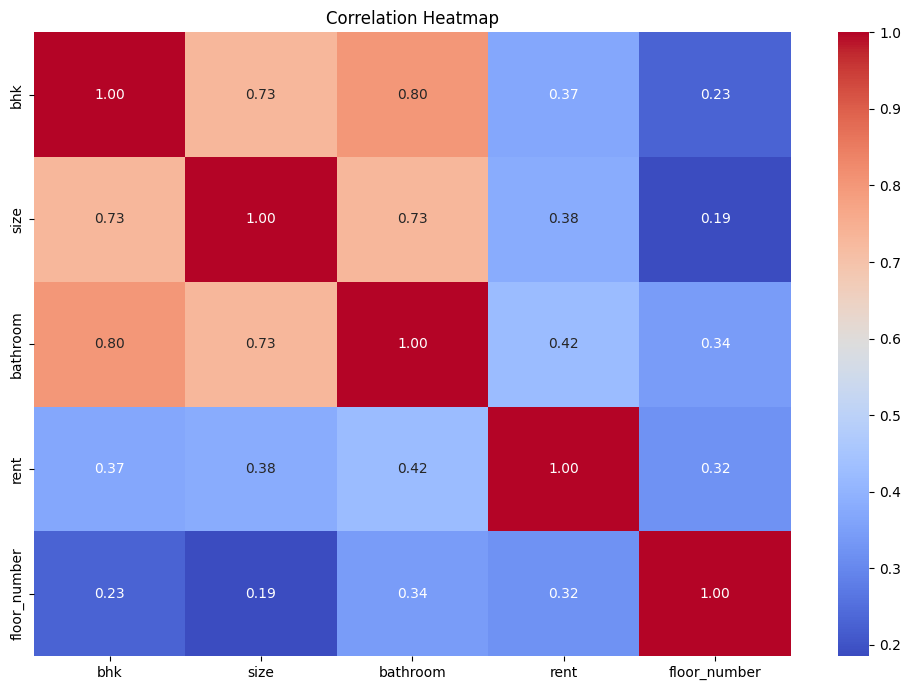

In [94]:
# Correlation heatmap — numeric features only
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

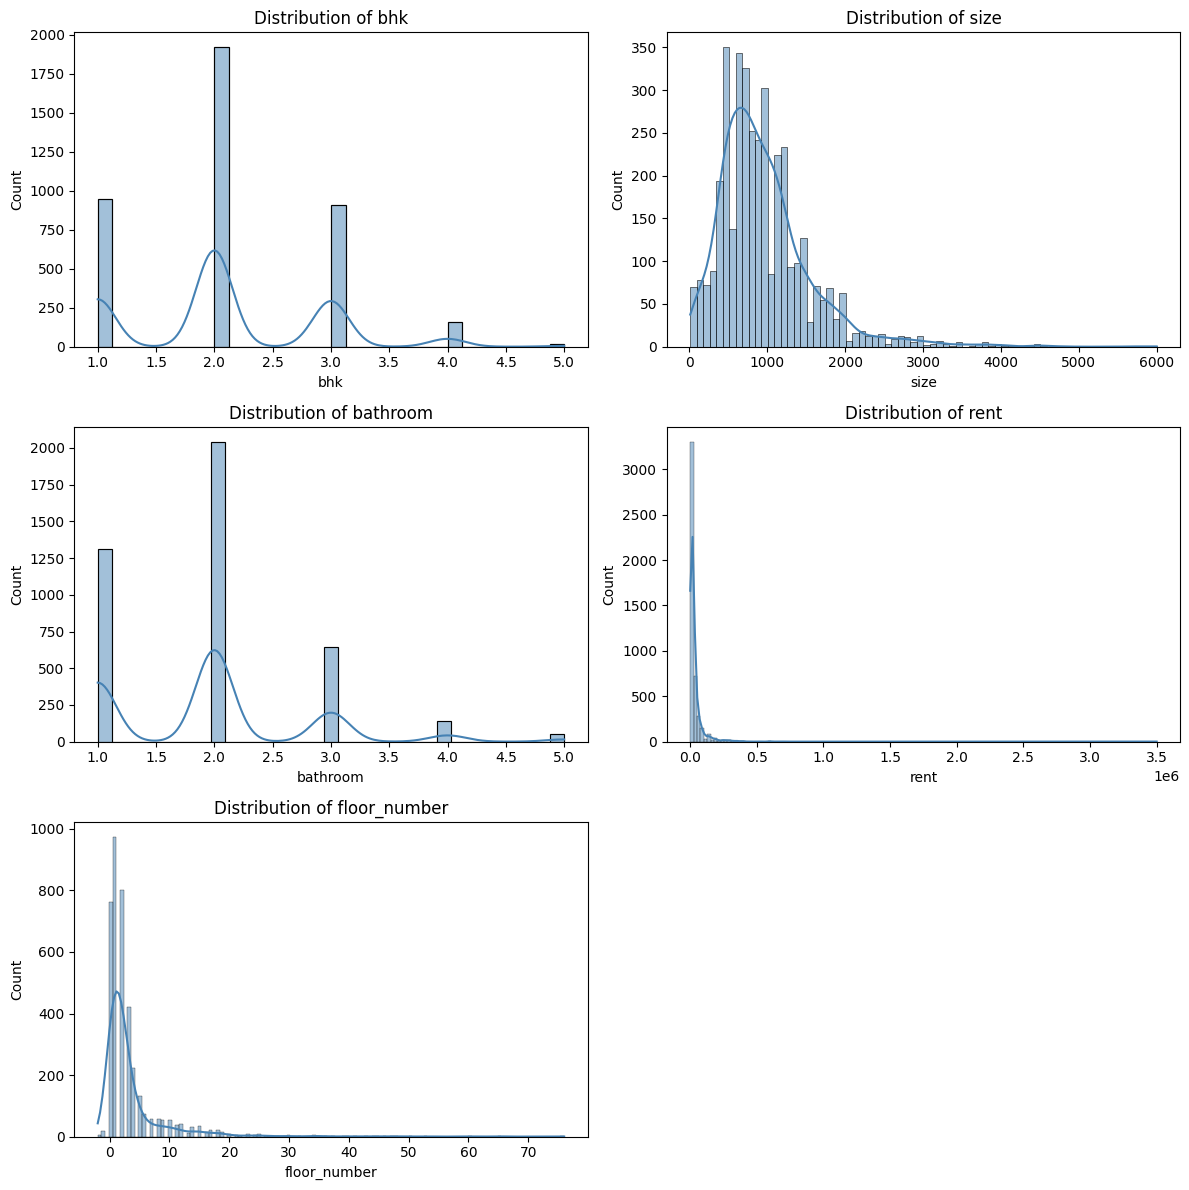

In [95]:
# Distribution of all numeric columns
numeric_cols = df.select_dtypes(include='number').columns
n = len(numeric_cols)
fig, axes = plt.subplots(math.ceil(n / 2), 2, figsize=(12, 4 * math.ceil(n / 2)))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], ax=axes[i], kde=True, color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

C:\Users\moham\AppData\Local\Temp\ipykernel_15508\2549373009.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='rent', ax=axes[i], palette='Blues_d')
C:\Users\moham\AppData\Local\Temp\ipykernel_15508\2549373009.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='rent', ax=axes[i], palette='Blues_d')
C:\Users\moham\AppData\Local\Temp\ipykernel_15508\2549373009.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='rent', ax=axes[i], palette='Blues_d')
C:\Users\moham\AppData\Local\Temp\ipy

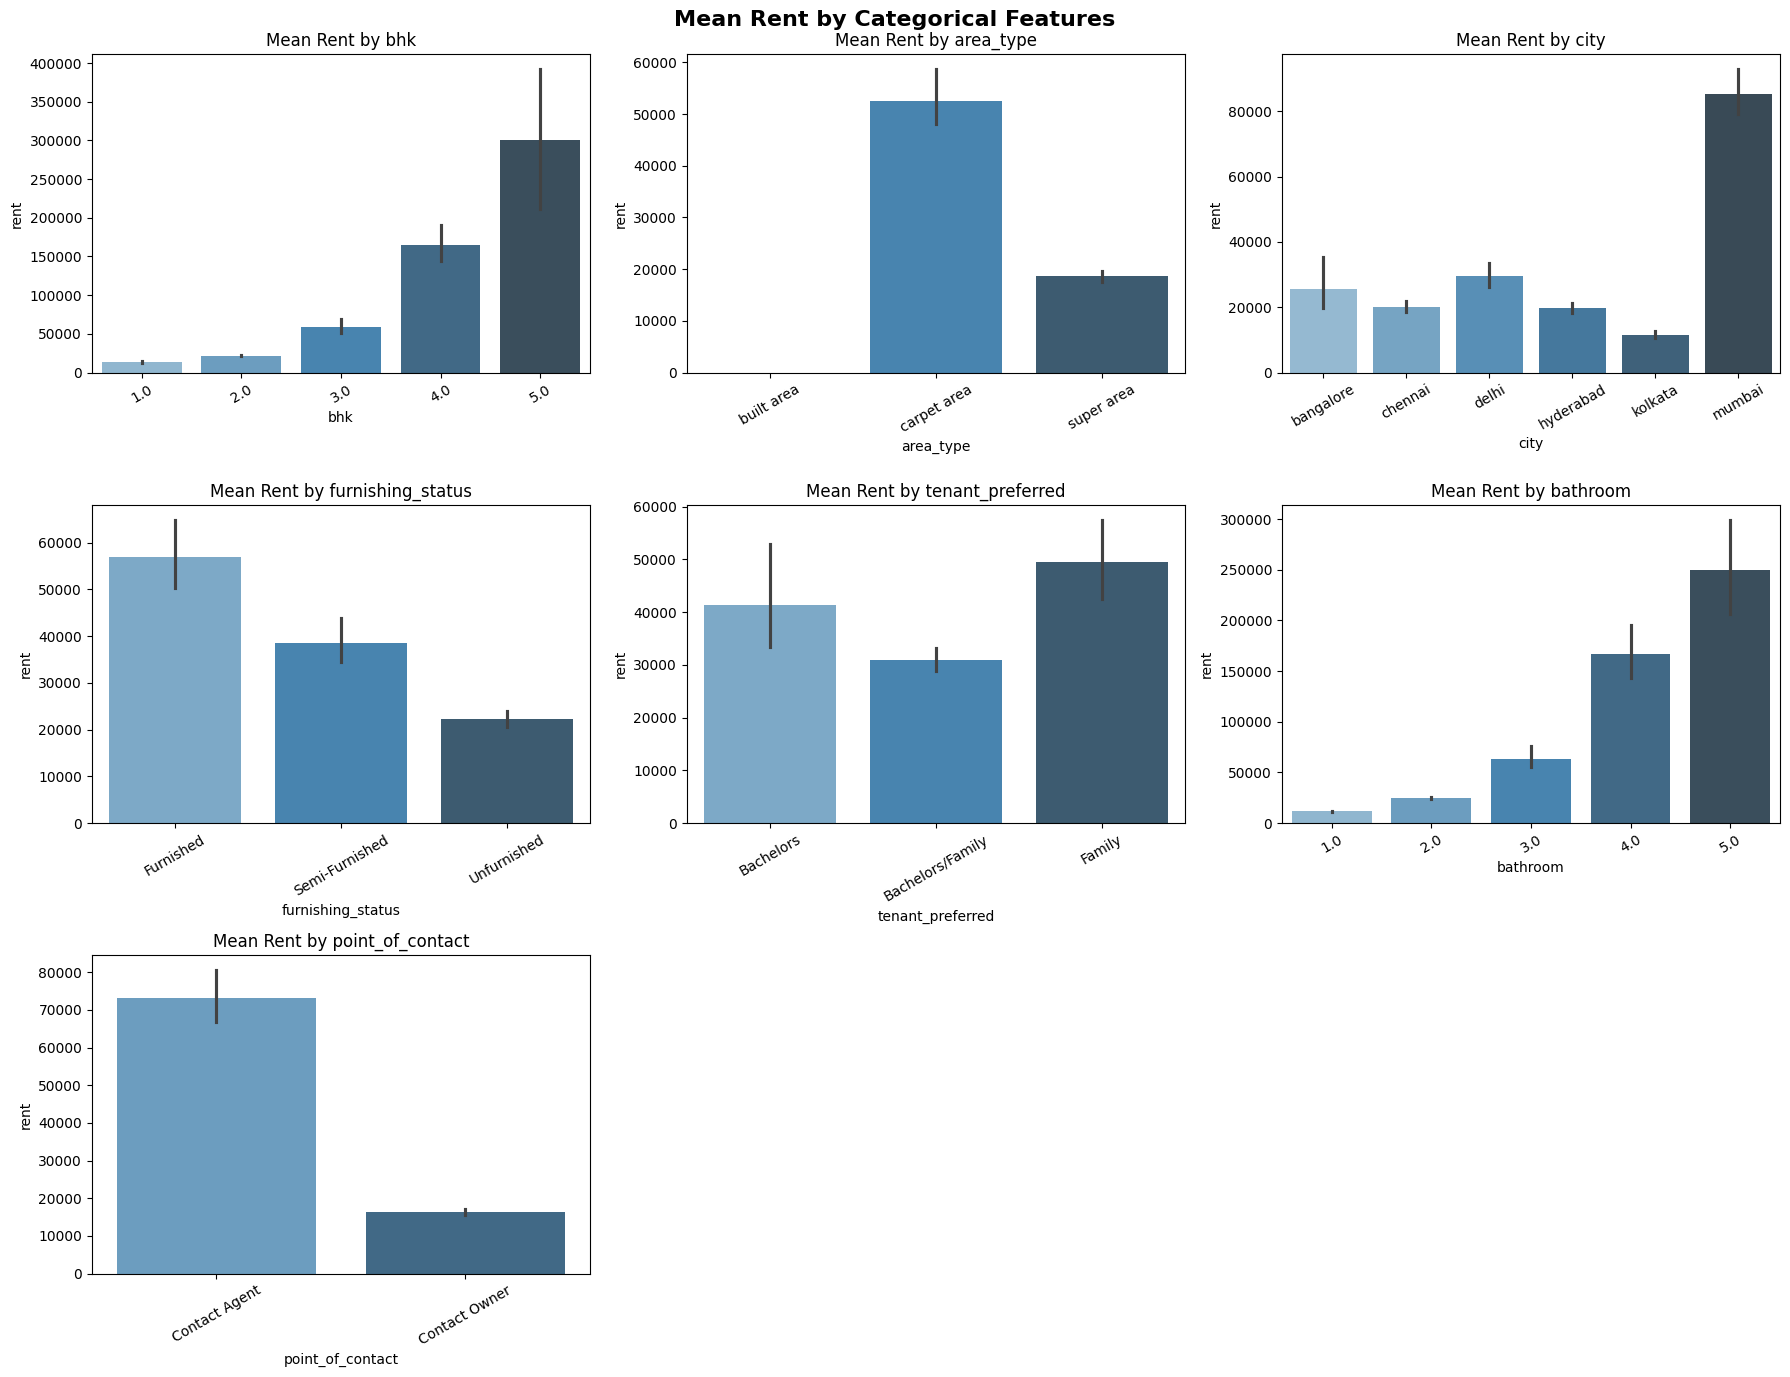

In [96]:
# Mean rent by categorical features
cat_cols = ['bhk', 'area_type', 'city', 'furnishing_status',
            'tenant_preferred', 'bathroom', 'point_of_contact']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.barplot(data=df, x=col, y='rent', ax=axes[i], palette='Blues_d')
    axes[i].set_title(f'Mean Rent by {col}', fontsize=12)
    axes[i].tick_params(axis='x', rotation=30)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Mean Rent by Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. Feature Engineering

**New features created:**

| Feature | Formula | Rationale |
|---|---|---|
| `post_month` | `posted_on.dt.month` | Seasonality signal |
| `days_since_posted` | `reference_date - posted_on` | Listing urgency |
| `size_per_bhk` | `size / bhk` | Space comfort per room |
| `bathroom_to_bhk` | `bathroom / bhk` | Luxury ratio |
| `total_floors` | extracted from `floor` string | Building height = luxury proxy |
| `floor_ratio` | `floor_number / total_floors` | Relative position in building |

**Features dropped after analysis:**
- `months_since_posted` — identical to days_since_posted / 30 (correlation = 1.0)
- `bhk_per_sqft` & `bathroom_per_sqft` — 0.93 correlated with each other, redundant
- `floor_number` — its information is captured by floor_ratio + total_floors combined
- `floor` (raw), `posted_on` (raw) — already extracted all needed info

**`area_locality` handling:**
- 2012 unique values → too high for OHE
- Solution: TargetEncoder inside the pipeline replaces locality with mean rent per area
- Fitted only on training folds (no leakage), rare localities blended toward global mean via smooth='auto'


In [97]:
reference_date = pd.Timestamp('2022-07-11')  # last date in dataset

# Time-based features
df['post_month']        = df['posted_on'].dt.month
df['days_since_posted'] = (reference_date - df['posted_on']).dt.days

# Property ratio features
df['size_per_bhk']    = df['size'] / df['bhk']      # comfort: space per bedroom
df['bathroom_to_bhk'] = df['bathroom'] / df['bhk']   # luxury ratio

# Floor features
# total_floors: proxy for building type (high-rise = luxury = higher rent)
# floor_ratio: relative position (top floor = better views = higher rent)
df['total_floors'] = df['floor'].astype(str).str.extract(r'out of\s+(\d+)')
df['total_floors'] = pd.to_numeric(df['total_floors'], errors='coerce')
df['floor_ratio']  = df['floor_number'] / df['total_floors']

df.shape

(4728, 19)

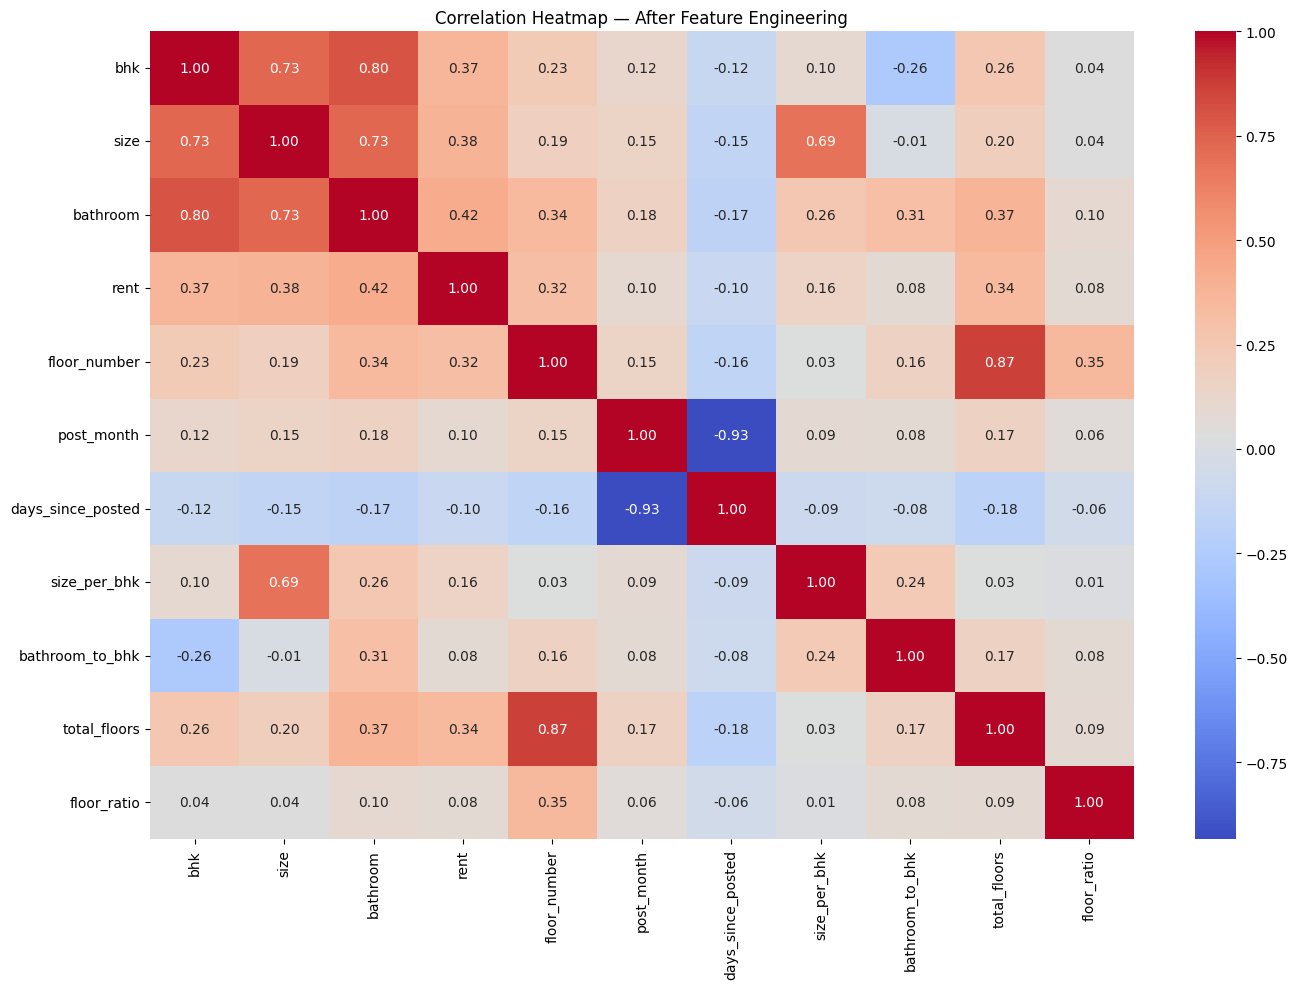

In [98]:
# Second correlation heatmap — after feature engineering
# Key insight: floor_ratio (0.13) and bathroom_to_bhk (0.17) are weak but non-zero
# tree models may still find non-linear value — keep for now, check feature importances later
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap — After Feature Engineering')
plt.tight_layout()
plt.show()

In [99]:
# Drop redundant and raw columns
# months_since_posted: same as days_since_posted / 30 — perfect multicollinearity
# bhk_per_sqft / bathroom_per_sqft: 0.93 correlated, redundant with existing columns
# floor_number: captured by floor_ratio + total_floors
# floor, posted_on: raw columns, extraction complete
df = df.drop(columns=[
    'floor_number',       # captured by floor_ratio + total_floors
    'floor',              # raw string, extraction done
    'posted_on',          # raw datetime, features extracted
])

df.columns

Index(['bhk', 'size', 'area_type', 'area_locality', 'city',
       'furnishing_status', 'tenant_preferred', 'bathroom', 'point_of_contact',
       'rent', 'post_month', 'days_since_posted', 'size_per_bhk',
       'bathroom_to_bhk', 'total_floors', 'floor_ratio'],
      dtype='str')

# 7. Train / Test Split + Outlier Capping

**IMPORTANT — order matters for data leakage prevention:**

 Wrong order: cap on full df → split → pipeline
 Correct order: split → cap using train stats only → pipeline

**Why IQR capping is done AFTER splitting:**
- IQR boundaries (Q1, Q3) are computed from the data
- If computed on full df, test set values influence the thresholds → leakage
- Fix: compute thresholds from X_train only, apply same thresholds to X_test

**Why IQR instead of 1st/99th percentile:**
- 1st/99th was too lenient — luxury Mumbai properties at ₹300K still leaked through
- IQR clips at Q3 + 1.5*IQR ≈ ₹65K — removes extreme luxury noise
- Result: RMSE dropped from ₹24,981 → ₹8,966

**Target: `rent_log` = log1p(rent)**
- Tree models don't require normally distributed targets — but log helps Linear Regression
- Predictions are back-transformed with np.expm1() for evaluation in actual rupees


In [100]:
from sklearn.model_selection import train_test_split

# Create target before splitting
# rent_log = log1p(rent) — reduces skewness from 3.6 to 0.84
# Back-transform predictions with np.expm1() to evaluate in rupees
y = np.log1p(df['rent'])
X = df.drop(columns=['rent']).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (3782, 15)
X_test:  (946, 15)
y_train: (3782,)
y_test:  (946,)


In [101]:
# Cap outliers AFTER split — using train stats only applied to both sets
# This prevents test set values from influencing the clipping thresholds

def cap_outliers_iqr(df_train, df_test, col):
    Q1    = df_train[col].quantile(0.25)
    Q3    = df_train[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_train = df_train.copy()
    df_test  = df_test.copy()
    df_train[col] = df_train[col].clip(lower, upper)
    df_test[col]  = df_test[col].clip(lower, upper)  # apply train bounds to test
    return df_train, df_test

X_train, X_test = cap_outliers_iqr(X_train, X_test, 'size')
y_train_df, y_test_df = cap_outliers_iqr(
    y_train.to_frame('rent'),
    y_test.to_frame('rent'),
    'rent')


# 8. Preprocessing Pipeline

**Design decisions:**

**Numerical** → `SimpleImputer(median)` + `StandardScaler`
- Median more robust to outliers than mean
- Scaling needed for Linear Regression and SVR (tree models ignore it but it doesn't hurt)

**Ordinal** → `SimpleImputer(most_frequent)` + `OrdinalEncoder`
- `furnishing_status` has natural order: Unfurnished=0 < Semi-Furnished=1 < Furnished=2
- Categories defined manually to ensure correct order (not alphabetical)

**Nominal** → `SimpleImputer(most_frequent)` + `OneHotEncoder(drop='first')`
- No natural order between city, area_type, tenant_preferred, point_of_contact
- `drop='first'` avoids dummy variable trap (multicollinearity for Linear Regression)
- `handle_unknown='ignore'` → unseen categories in test set return all zeros

**Target (area_locality)** → `SimpleImputer(most_frequent)` + `TargetEncoder(smooth='auto')`
- 2012 unique localities → OHE would create 2000+ columns
- TargetEncoder replaces each locality with mean rent — 1 column, meaningful signal
- `smooth='auto'` blends rare localities toward global mean (shrinkage)
- Fitted only on training data inside cross-validation folds → no leakage

**Why SimpleImputer over custom ProbabilityImputer:**
- ProbabilityImputer introduced randomness (different results each run)
- ProbabilityImputer lacks `get_feature_names_out()` — breaks sklearn compatibility
- SimpleImputer is deterministic, fully sklearn-compatible, works inside ColumnTransformer


In [102]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ── Feature lists ──────────────────────────────────────────────────────────
num_attr     = ['size', 'bhk', 'bathroom', 'days_since_posted',
                'post_month', 'size_per_bhk', 'bathroom_to_bhk',
                'total_floors', 'floor_ratio']

ordinal_attr = ['furnishing_status']   # ordinal: natural order exists
nominal_attr = ['city', 'area_type', 'tenant_preferred', 'point_of_contact']  # nominal: no order
target_attr  = ['area_locality']       # high cardinality → TargetEncoder

# ── Sub-pipelines ──────────────────────────────────────────────────────────
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # robust to outliers
    ('scaler',  StandardScaler())                   # needed for LR and SVR
])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(
        # Explicit order — sklearn default is alphabetical which would be wrong
        categories=[['Unfurnished', 'Semi-Furnished', 'Furnished']],
        handle_unknown='use_encoded_value',  # unseen value → -1 (not a crash)
        unknown_value=-1
    ))
])

nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(
        drop='first',           # avoid dummy variable trap (multicollinearity)
        sparse_output=False,    # return dense array for compatibility
        handle_unknown='ignore' # unseen category → all zeros row
    ))
])

target_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # TargetEncoder uses y (rent_log) during fit to compute mean rent per locality
    # smooth='auto': rare localities blended toward global mean to avoid overfitting
    # Fitted only on training data — no leakage when used inside pipeline with CV
    ('target',  TargetEncoder(smooth='auto'))
])

# ── ColumnTransformer — routes each column to the right pipeline ───────────
preprocessor = ColumnTransformer([
    ('num',     num_pipeline,     num_attr),
    ('ordinal', ordinal_pipeline, ordinal_attr),
    ('nominal', nominal_pipeline, nominal_attr),
    ('target',  target_pipeline,  target_attr),
], remainder='drop')  # drop any column not explicitly listed above

# ── Fit on train, transform both ───────────────────────────────────────────
# Pass y_train so TargetEncoder can compute mean rent per locality
X_train_prep = preprocessor.fit_transform(X_train, y_train)
X_test_prep  = preprocessor.transform(X_test)

print("X_train_prep shape:", X_train_prep.shape)
print("X_test_prep shape: ", X_test_prep.shape)

X_train_prep shape: (3782, 20)
X_test_prep shape:  (946, 20)


# 9. Model Comparison

**Models compared:**
- Linear Regression — baseline, assumes linear relationships
- Decision Tree — non-linear but prone to overfitting without ensembling
- Random Forest — ensemble of trees, robust to outliers and non-linearity
- SVR — kernel-based, good for medium datasets
- XGBoost — gradient boosting, often best on tabular data

**Evaluation metrics:**
- **CV RMSE (log scale)** — cross-validated on training set, honest estimate of generalisation
- **Test RMSE (₹)** — final evaluation on held-out test set, back-transformed with np.expm1()
- **MAE (₹)** — mean absolute error, less sensitive to large errors than RMSE
- **R²** — proportion of rent variance explained by the model (0 to 1, higher is better)

**Why RMSE > MAE always:**
RMSE squares errors before averaging — large mistakes get amplified.
A big gap between RMSE and MAE means a few properties have very large errors.

**Cross-validation uses the full pipeline** to prevent TargetEncoder leakage across folds.


In [103]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree':     DecisionTreeRegressor(random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42),
    'SVR':               SVR(),
    'XGBoost':           XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

print(f"{'Model':25s} | {'CV RMSE':>10} | {'CV STD':>8} | {'Test RMSE (₹)':>14} | {'MAE (₹)':>10} | {'R²':>6}")
print("-" * 85)

for name, model in models.items():
    # Wrap in full pipeline — ensures TargetEncoder is refitted on each CV fold
    full_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model',        model)
    ])

    # CV on raw X_train — preprocessor fitted fresh on each fold (no leakage)
    cv_rmse = -cross_val_score(full_pipeline, X_train, y_train,
                                scoring='neg_root_mean_squared_error', cv=5, n_jobs=-1)

    # # Final evaluation on test set
    # full_pipeline.fit(X_train, y_train)
    # y_pred_actual = np.expm1(full_pipeline.predict(X_test))
    # y_test_actual = np.expm1(y_test)

    # test_rmse = root_mean_squared_error(y_test_actual, y_pred_actual)
    # mae       = mean_absolute_error(y_test_actual, y_pred_actual)
    # r2        = r2_score(y_test_actual, y_pred_actual)

    # print(f"{name:25s} | {cv_rmse.mean():>10.4f} | {cv_rmse.std():>8.4f} | "
    #       f"{test_rmse:>14,.0f} | {mae:>10,.0f} | {r2:>6.4f}")

Model                     |    CV RMSE |   CV STD |  Test RMSE (₹) |    MAE (₹) |     R²
-------------------------------------------------------------------------------------


# 10. Hyperparameter Tuning — Random Forest

**Why Random Forest won:**
- Best Test RMSE and R² across all models
- Robust to outliers and multicollinearity (bhk/bathroom correlation = 0.80)
- Feature importances give explainability

**GridSearchCV with full pipeline:**
- `model__param` prefix accesses model params inside the pipeline
- CV refits the full pipeline (including preprocessor) on each fold
- `n_jobs=-1` uses all CPU cores for parallel fitting


In [104]:
param_grid = {
    'model__n_estimators':      [100, 200, 300],
    'model__max_depth':         [10, 20, None],
    'model__min_samples_split': [2, 5, 10],
    'model__max_features':      ['sqrt', 'log2']
}

tuned_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',        RandomForestRegressor(random_state=42))
])

grid_search = GridSearchCV(
    tuned_pipeline,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best params: ", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best params:  {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best CV RMSE: 0.4429109624907051


# 11. Final Evaluation on Test Set

In [105]:
y_pred_actual = np.expm1(grid_search.best_estimator_.predict(X_test))
y_test_actual = np.expm1(y_test)

print("Tuned Random Forest — Final Test Results:")
print(f"  RMSE: ₹{root_mean_squared_error(y_test_actual, y_pred_actual):,.0f}")
print(f"  MAE:  ₹{mean_absolute_error(y_test_actual, y_pred_actual):,.0f}")
print(f"  R²:   {r2_score(y_test_actual, y_pred_actual):.4f}")

Tuned Random Forest — Final Test Results:
  RMSE: ₹28,713
  MAE:  ₹11,025
  R²:   0.6604
